In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a clean visual theme
sns.set_theme(style="whitegrid")

# Load the data (assuming the notebook is in the same folder as the CSV)
df = pd.read_csv("results/results_detailed.csv")

# Quick preview
display(df.head())

,model,experiment,subject,accuracy,precision,recall,specificity,f1,roc_auc,tn,fp,fn,tp
0,rf,chest_acc,S2,0.666667,0.666667,0.173913,0.95000,0.275862,0.942935,38,2,19,4
1,rf,chest_acc,S3,0.718750,0.875000,0.291667,0.97500,0.437500,0.958333,39,1,17,7
2,rf,chest_acc,S4,0.746032,1.000000,0.304348,1.00000,0.466667,0.999457,40,0,16,7
3,rf,chest_acc,S5,0.906250,1.000000,0.739130,1.00000,0.850000,0.993637,41,0,6,17
4,rf,chest_acc,S6,0.830769,0.933333,0.583333,0.97561,0.717949,0.961382,40,1,10,14


In [2]:
df.shape

(495, 13)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 495 entries, 0 to 494
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   model        495 non-null    object 
 1   experiment   495 non-null    object 
 2   subject      495 non-null    object 
 3   accuracy     495 non-null    float64
 4   precision    495 non-null    float64
 5   recall       495 non-null    float64
 6   specificity  495 non-null    float64
 7   f1           495 non-null    float64
 8   roc_auc      495 non-null    float64
 9   tn           495 non-null    int64  
 10  fp           495 non-null    int64  
 11  fn           495 non-null    int64  
 12  tp           495 non-null    int64  
dtypes: float64(6), int64(4), object(3)
memory usage: 50.4+ KB


In [13]:
print("\nColumns:")
display(df.columns)

print("\nUnique Models:")
display(df['model'].unique())

print("\nNumber of Models:")
display(df['model'].nunique())


Columns:


Index(['model', 'experiment', 'subject', 'accuracy', 'precision', 'recall',
       'specificity', 'f1', 'roc_auc', 'tn', 'fp', 'fn', 'tp'],
      dtype='object')


Unique Models:


array(['rf', 'svm', 'xgboost'], dtype=object)


Number of Models:


3

In [15]:
display(df['experiment'].unique())

array(['chest_acc', 'chest_eda', 'chest_emg', 'chest_heart',
       'chest_statistical', 'wrist_acc', 'wrist_eda', 'wrist_heart',
       'wrist_statistical', 'chest_all', 'wrist_all'], dtype=object)

In [16]:
metrics = [
    'accuracy',
    'precision',
    'recall',
    'specificity',
    'f1',
    'roc_auc'
]

model_summary = df.groupby('model')[metrics].agg(['mean', 'std','var'])

print("\nModel Summary:")
display(
    model_summary.style
    .background_gradient(cmap='Blues')
    .format("{:.3f}")
)

mean_performance = df.groupby('model')[metrics].mean().round(4)

print("\nMean Performance:")
display(mean_performance)



Model Summary:



Mean Performance:


,accuracy,precision,recall,specificity,f1,roc_auc
model,,,,,,
rf,0.8123,0.8107,0.7031,0.8777,0.7115,0.9045
svm,0.8142,0.7793,0.7868,0.8311,0.7495,0.8870
xgboost,0.8276,0.8214,0.7655,0.8649,0.7576,0.9151


In [18]:
print("\nBest Models Per Metric:")

for metric in metrics:
    best_model = mean_performance[metric].idxmax()
    best_score = mean_performance[metric].max()

    display(f"{metric}: {best_model} -> {best_score:.4f}")

rank_table = mean_performance.rank(ascending=False)
rank_table['average_rank'] = rank_table.mean(axis=1)
rank_table = rank_table.sort_values('average_rank')

print("\nModel Rankings:")
display(rank_table)


Best Models Per Metric:


'accuracy: xgboost -> 0.8276'

'precision: xgboost -> 0.8214'

'recall: svm -> 0.7868'

'specificity: rf -> 0.8777'

'f1: xgboost -> 0.7576'

'roc_auc: xgboost -> 0.9151'


Model Rankings:


,accuracy,precision,recall,specificity,f1,roc_auc,average_rank
model,,,,,,,
xgboost,1.0,1.0,2.0,2.0,1.0,1.0,1.333333
rf,3.0,2.0,3.0,1.0,3.0,2.0,2.333333
svm,2.0,3.0,1.0,3.0,2.0,3.0,2.333333


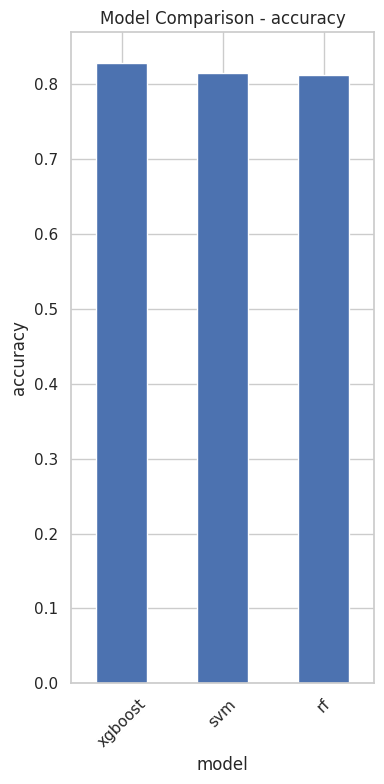

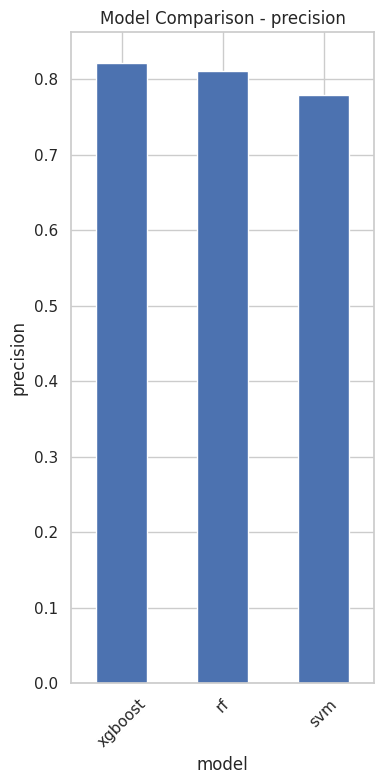

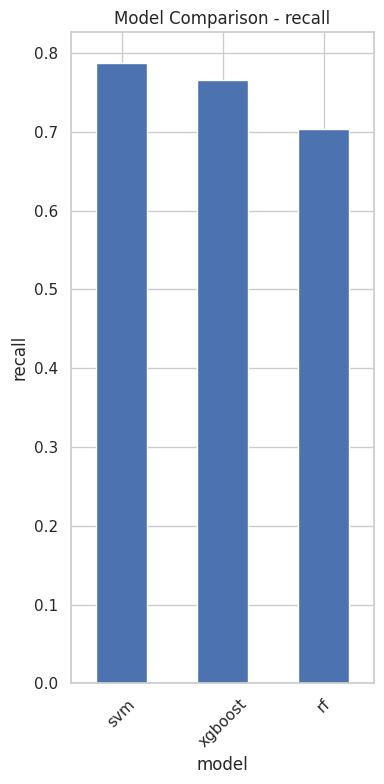

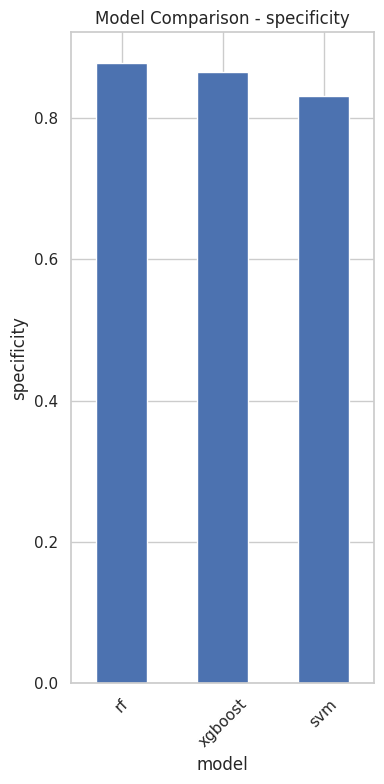

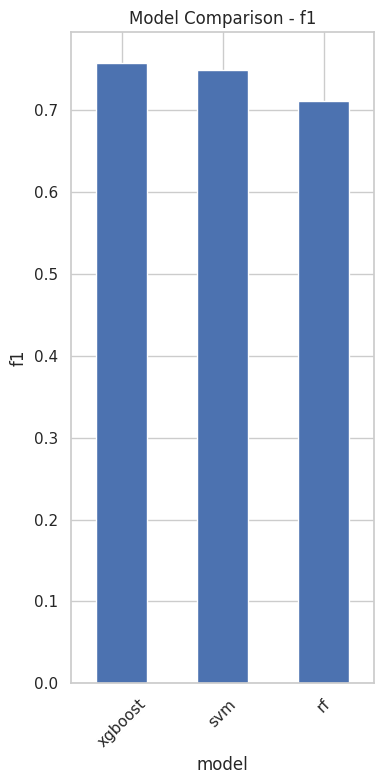

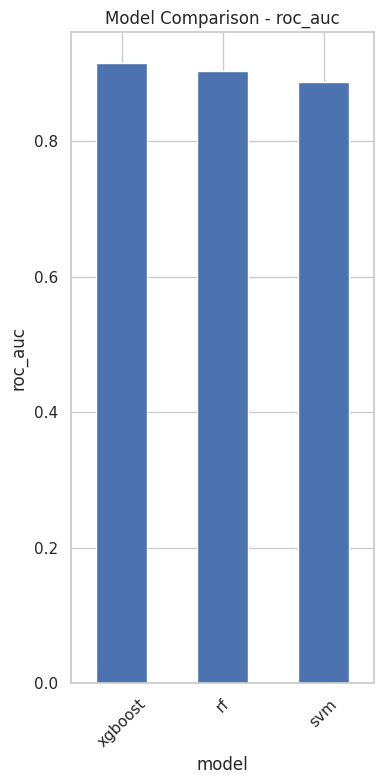

In [24]:
for metric in metrics:
    plt.figure(figsize=(4, 8))

    mean_performance[metric].sort_values(ascending=False).plot(kind='bar')

    plt.title(f'Model Comparison - {metric}')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [26]:
subject_analysis = df.groupby(['subject', 'model'])[metrics].mean()

print("\nSubject-wise Analysis:")
display(subject_analysis)


Subject-wise Analysis:


accuracy  precision    recall  specificity        f1  \
subject model                                                           
S10     rf       0.736771   0.818617  0.601399     0.822616  0.594270   
        svm      0.774763   0.726683  0.842657     0.731707  0.747434   
        xgboost  0.789688   0.823088  0.765734     0.804878  0.727649   
S11     rf       0.850746   0.832130  0.803636     0.878788  0.788621   
        svm      0.896879   0.844759  0.909091     0.889610  0.866051   
        xgboost  0.867028   0.831075  0.869091     0.865801  0.828849   
S13     rf       0.845730   0.817017  0.844697     0.846320  0.811868   
        svm      0.812672   0.717459  0.939394     0.740260  0.802002   
        xgboost  0.820937   0.776637  0.875000     0.790043  0.800662   
S14     rf       0.791193   0.754099  0.609848     0.900000  0.616789   
        svm      0.788352   0.745241  0.696970     0.843182  0.685464   
        xgboost  0.809659   0.768583  0.666667     0.895455  0.656427   
S15     rf       0.800275   0.856336  0.578182     0.935698  0.662011   
        svm      0.803030   0.808667  0.658182     0.891353  0.703858   
        xgboost  0.819559   0.852773  0.650909     0.922395  0.715301   
S16     rf       0.916084   0.920323  0.935606     0.904656  0.909821   
        svm      0.893706   0.868590  0.943182     0.864745  0.888490   
        xgboost  0.910490   0.906339  0.928030     0.900222  0.905273   
S17     rf       0.781547   0.761750  0.604895     0.893570  0.640273   
        svm      0.833107   0.789198  0.699301     0.917960  0.713392   
        xgboost  0.831750   0.814206  0.720280     0.902439  0.739617   
S2      rf       0.756133   0.784576  0.545455     0.877273  0.603323   
        svm      0.759019   0.652707  0.671937     0.809091  0.626921   
        xgboost  0.810967   0.787073  0.747036     0.847727  0.750439   
S3      rf       0.791193   0.746971  0.685606     0.854545  0.680723   
        svm      0.791193   0.783720  0.636364     0.884091  0.655705   
        xgboost  0.823864   0.777999  0.750000     0.868182  0.740673   
S4      rf       0.835498   0.851928  0.600791     0.970455  0.673121   
        svm      0.900433   0.934573  0.790514     0.963636  0.815356   
        xgboost  0.855700   0.937146  0.664032     0.965909  0.739469   
S5      rf       0.833807   0.848366  0.707510     0.904656  0.714402   
        svm      0.860795   0.819212  0.822134     0.882483  0.783443   
        xgboost  0.823864   0.830936  0.750988     0.864745  0.727887   
S6      rf       0.813986   0.799416  0.651515     0.909091  0.688124   
        svm      0.858741   0.861896  0.757576     0.917960  0.790693   
        xgboost  0.841958   0.871784  0.689394     0.931264  0.748037   
S7      rf       0.744318   0.655791  0.897233     0.658537  0.733059   
        svm      0.609375   0.529791  0.889328     0.452328  0.631017   
        xgboost  0.730114   0.659590  0.909091     0.629712  0.736135   
S8      rf       0.859504   0.875250  0.756364     0.922395  0.799318   
        svm      0.822314   0.783290  0.810909     0.829268  0.783918   
        xgboost  0.873278   0.883549  0.796364     0.920177  0.819980   
S9      rf       0.828125   0.837729  0.723320     0.886918  0.757482   
        svm      0.808239   0.823748  0.735178     0.849224  0.748760   
        xgboost  0.805398   0.800719  0.699605     0.864745  0.727790   

                  roc_auc  
subject model              
S10     rf       0.861035  
        svm      0.895915  
        xgboost  0.873103  
S11     rf       0.958831  
        svm      0.963550  
        xgboost  0.953247  
S13     rf       0.928887  
        svm      0.905032  
        xgboost  0.922529  
S14     rf       0.886364  
        svm      0.860133  
        xgboost  0.906534  
S15     rf       0.885632  
        svm      0.877960  
        xgboost  0.904479  
S16     rf       0.951127  
        svm      0.907982  
        xgboost  0.945122  
S17     rf       0.836688

In [27]:
experiment_analysis = df.groupby(['experiment', 'model'])[metrics].mean()

print("\nExperiment-wise Analysis:")
display(experiment_analysis)


Experiment-wise Analysis:


accuracy  precision    recall  specificity  \
experiment        model                                                 
chest_acc         rf       0.813557   0.839564  0.659152     0.905391   
                  svm      0.811183   0.758870  0.828755     0.800943   
                  xgboost  0.836480   0.854672  0.738252     0.895515   
chest_all         rf       0.886742   0.930598  0.772070     0.956049   
                  svm      0.904613   0.895514  0.851575     0.936218   
                  xgboost  0.920996   0.927372  0.855210     0.959454   
chest_eda         rf       0.805924   0.800340  0.702688     0.871088   
                  svm      0.757764   0.706677  0.695014     0.799959   
                  xgboost  0.776688   0.786247  0.702632     0.825405   
chest_emg         rf       0.563881   0.444643  0.427955     0.649053   
                  svm      0.580889   0.511235  0.648970     0.544847   
                  xgboost  0.585399   0.518411  0.549892     0.611796   
chest_heart       rf       0.804709   0.820065  0.735058     0.841409   
                  svm      0.807202   0.796637  0.739193     0.843076   
                  xgboost  0.799827   0.802536  0.755700     0.822166   
chest_statistical rf       0.868981   0.865166  0.722971     0.955968   
                  svm      0.838237   0.823522  0.753145     0.887555   
                  xgboost  0.914023   0.921665  0.856247     0.947712   
wrist_acc         rf       0.806191   0.853364  0.680740     0.881249   
                  svm      0.821128   0.808267  0.782645     0.845592   
                  xgboost  0.834105   0.857851  0.755890     0.881367   
wrist_all         rf       0.897192   0.930972  0.809759     0.949106   
                  svm      0.929192   0.914132  0.917213     0.936734   
                  xgboost  0.915644   0.925731  0.884865     0.932805   
wrist_eda         rf       0.822283   0.759820  0.700044     0.896765   
                  svm      0.789180   0.728216  0.701631     0.843848   
                  xgboost  0.804876   0.753980  0.701415     0.867646   
wrist_heart       rf       0.836126   0.790804  0.792581     0.860139   
                  svm      0.854492   0.768911  0.896170     0.829113   
                  xgboost  0.830202   0.775456  0.801388     0.845461   
wrist_statistical rf       0.830015   0.882219  0.730758     0.888496   
                  svm      0.862041   0.860343  0.841015     0.874506   
                  xgboost  0.885545   0.911842  0.818802     0.924715   

                                 f1   roc_auc  
experiment        model                        
chest_acc         rf       0.686551  0.929855  
                  svm      0.771638  0.920469  
                  xgboost  0.756496  0.950086  
chest_all         rf       0.800214  0.987778  
                  svm      0.844359  0.947461  
                  xgboost  0.873524  0.986182  
chest_eda         rf       0.699918  0.915129  
                  svm      0.666074  0.828079  
                  xgboost  0.692192  0.891312  
chest_emg         rf       0.378554  0.608190  
                  svm      0.521611  0.651980  
                  xgboost  0.476270  0.645794  
chest_heart       rf       0.718605  0.910874  
                  svm      0.716608  0.917562  
                  xgboost  0.723982  0.928070  
chest_statistical rf       0.743449  0.973738  
                  svm      0.729172  0.850709  
                  xgboost  0.857851  0.986782  
wrist_acc         rf       0.721198  0.901409  
                  svm      0.774243  0.913456  
                  xgboost  0.774381  0.919120  
wrist_all         rf       0.848682  0.972596  
                  svm      0.906425  0.990693  
                  xgboost  0.882974  0.992064  
wrist_eda         rf       0.709804  0.899670  
                  svm      0.674505  0.855829  
                  xgboost  0.704799  0.897219  
wrist_heart       rf       0.773874  0.905070  
                  svm      0.81

In [30]:
# FALSE POSITIVE / FALSE NEGATIVE ANALYSIS
confusion_totals = df.groupby(['experiment','model'])[['tn', 'fp', 'fn', 'tp']].sum()

print("\nConfusion Matrix Totals:")
display(confusion_totals)



Confusion Matrix Totals:


tn   fp   fn   tp
experiment        model                      
chest_acc         rf       555   58  123  239
                  svm      491  122   62  300
                  xgboost  549   64   95  267
chest_all         rf       586   27   83  279
                  svm      574   39   53  309
                  xgboost  588   25   51  311
chest_eda         rf       534   79  111  251
                  svm      490  123  114  248
                  xgboost  506  107  111  251
chest_emg         rf       398  215  209  153
                  svm      334  279  128  234
                  xgboost  375  238  165  197
chest_heart       rf       515   98   93  269
                  svm      516   97   91  271
                  xgboost  503  110   86  276
chest_statistical rf       586   27  100  262
                  svm      544   69   87  275
                  xgboost  581   32   51  311
wrist_acc         rf       540   73  116  246
                  svm      518   95   80  282
                  xgboost  540   73   89  273
wrist_all         rf       582   31   69  293
                  svm      574   39   30  332
                  xgboost  572   41   41  321
wrist_eda         rf       549   64  110  252
                  svm      517   96  110  252
                  xgboost  531   82  109  253
wrist_heart       rf       527   86   74  288
                  svm      508  105   37  325
                  xgboost  518   95   71  291
wrist_statistical rf       545   68   98  264
                  svm      536   77   57  305
                  xgboost  567   46   65  297

In [35]:
confusion_totals['fpr_like'] = confusion_totals['fp'] / (
    confusion_totals['fp'] + confusion_totals['tn']
)

confusion_totals['fnr_like'] = confusion_totals['fn'] / (
    confusion_totals['fn'] + confusion_totals['tp']
)

print("\nError Analysis:")
display(confusion_totals[['fpr_like', 'fnr_like']])


Error Analysis:


fpr_like  fnr_like
experiment        model                      
chest_acc         rf       0.094617  0.339779
                  svm      0.199021  0.171271
                  xgboost  0.104405  0.262431
chest_all         rf       0.044046  0.229282
                  svm      0.063622  0.146409
                  xgboost  0.040783  0.140884
chest_eda         rf       0.128874  0.306630
                  svm      0.200653  0.314917
                  xgboost  0.174551  0.306630
chest_emg         rf       0.350734  0.577348
                  svm      0.455139  0.353591
                  xgboost  0.388254  0.455801
chest_heart       rf       0.159869  0.256906
                  svm      0.158238  0.251381
                  xgboost  0.179445  0.237569
chest_statistical rf       0.044046  0.276243
                  svm      0.112561  0.240331
                  xgboost  0.052202  0.140884
wrist_acc         rf       0.119086  0.320442
                  svm      0.154976  0.220994
                  xgboost  0.119086  0.245856
wrist_all         rf       0.050571  0.190608
                  svm      0.063622  0.082873
                  xgboost  0.066884  0.113260
wrist_eda         rf       0.104405  0.303867
                  svm      0.156607  0.303867
                  xgboost  0.133768  0.301105
wrist_heart       rf       0.140294  0.204420
                  svm      0.171289  0.102210
                  xgboost  0.154976  0.196133
wrist_statistical rf       0.110930  0.270718
                  svm      0.125612  0.157459
                  xgboost  0.075041  0.179558

In [38]:
stability = df.groupby(['model','experiment'])[metrics].std().round(4)

print("\nModel Stability (Lower STD = More Stable):")
display(stability)
mean_performance['overall_score'] = mean_performance.mean(axis=1)

best_overall_model = mean_performance['overall_score'].idxmax()

print("\nBest Overall Model:")
display(best_overall_model)

print("\nOverall Scores:")
display(mean_performance['overall_score'].sort_values(ascending=False))



print("\nAnalysis completed successfully.")


Model Stability (Lower STD = More Stable):


accuracy  precision  recall  specificity      f1  \
model   experiment                                                            
rf      chest_acc            0.1053     0.1450  0.3122       0.1291  0.2258   
        chest_all            0.1032     0.0938  0.2972       0.0684  0.2287   
        chest_eda            0.1031     0.1493  0.2994       0.1364  0.2023   
        chest_emg            0.1336     0.1532  0.2918       0.3112  0.1883   
        chest_heart          0.1470     0.1937  0.2799       0.2531  0.2281   
        chest_statistical    0.1183     0.2553  0.3501       0.0634  0.3130   
        wrist_acc            0.1251     0.1778  0.2128       0.2159  0.1385   
        wrist_all            0.0719     0.1198  0.1717       0.1024  0.1155   
        wrist_eda            0.1205     0.2721  0.2957       0.1381  0.2752   
        wrist_heart          0.1194     0.1520  0.2272       0.1584  0.1730   
        wrist_statistical    0.1318     0.2056  0.2644       0.2008  0.2214   
svm     chest_acc            0.1529     0.1894  0.1983       0.2303  0.1678   
        chest_all            0.1254     0.1814  0.2872       0.1120  0.2395   
        chest_eda            0.1697     0.2046  0.3045       0.2450  0.2217   
        chest_emg            0.1650     0.1691  0.2875       0.3544  0.1511   
        chest_heart          0.1429     0.1999  0.3051       0.2257  0.2333   
        chest_statistical    0.1744     0.2867  0.3704       0.2250  0.3360   
        wrist_acc            0.1580     0.1865  0.1870       0.2333  0.1562   
        wrist_all            0.0630     0.1094  0.1162       0.0963  0.0771   
        wrist_eda            0.1093     0.1734  0.3065       0.1412  0.2523   
        wrist_heart          0.0791     0.1068  0.1576       0.1031  0.1081   
        wrist_statistical    0.1199     0.1730  0.1896       0.2007  0.1317   
xgboost chest_acc            0.1113     0.1541  0.2501       0.1651  0.1711   
        chest_all            0.0816     0.0819  0.2131       0.0453  0.1557   
        chest_eda            0.1459     0.1898  0.2723       0.2568  0.1711   
        chest_emg            0.1523     0.1564  0.2697       0.3350  0.1519   
        chest_heart          0.1501     0.2054  0.2754       0.2616  0.2160   
        chest_statistical    0.0918     0.1059  0.2461       0.0704  0.1999   
        wrist_acc            0.1265     0.1786  0.1913       0.2071  0.1400   
        wrist_all            0.0877     0.1416  0.1805       0.1339  0.1330   
        wrist_eda            0.1110     0.2720  0.2540       0.1646  0.2292   
        wrist_heart          0.1215     0.1511  0.2184       0.1645  0.1702   
        wrist_statistical    0.1205     0.1599  0.2677       0.1467  0.2330   

                           roc_auc  
model   experiment                  
rf      chest_acc           0.0804  
        chest_all           0.0174  
        chest_eda           0.0703  
        chest_emg           0.1666  
        chest_heart         0.1060  
        chest_statistical   0.0470  
        wrist_acc           0.1001  
        wrist_all           0.0590  
        wrist_eda           0.1027  
        wrist_heart         0.0983  
        wrist_statistical   0.1181  
svm     chest_acc           0.0778  
        chest_all           0.1517  
        chest_eda           0.2045  
        chest_emg           0.1954  
        chest_heart         0.1167  
        chest_statistical   0.2949  
        wrist_acc           0.1065  
        wrist_all           0.0158  
        wrist_eda           0.1242  
        wrist_heart         0.0645  
        wrist_statistical   0.1025  
xgboost chest_acc           0.0759  
        chest_all           0.0262  
        chest_eda           0.1025  
        chest_emg           0.1621  
        chest_heart         0.1012  
        chest_statistical   0.0257  
        wrist_acc           0.0680  
        wrist_all           0.0109  
        wrist_eda           0.0823  
        wrist_heart         0.0870  
   


Best Overall Model:


'xgboost'


Overall Scores:


model
xgboost    0.825350
svm        0.807983
rf         0.803300
Name: overall_score, dtype: float64


Analysis completed successfully.


In [41]:
metrics = [
    'accuracy',
    'precision',
    'recall',
    'specificity',
    'f1',
    'roc_auc'
]

mean_performance = (
    df.groupby('model')[metrics]
    .mean()
    .round(4)
)
for metric in metrics:
    best_model = mean_performance[metric].idxmax()
    best_score = mean_performance[metric].max()

    display(f"Best {metric}: {best_model} --> {best_score:.4f}")

'Best accuracy: xgboost --> 0.8276'

'Best precision: xgboost --> 0.8214'

'Best recall: svm --> 0.7868'

'Best specificity: rf --> 0.8777'

'Best f1: xgboost --> 0.7576'

'Best roc_auc: xgboost --> 0.9151'